# Edges vs. Coverage

Plots the per-node out-degree (x-axis, log scale) against `log(1 - coverage)` (y-axis), where coverage is the fraction of points covered. This is the inverse view of the degree-vs-coverage figure.

Reads the `edge_to_coverage_stats_{dataset}.csv` files written by `edge_to_coverage_analysis.py`. Columns:
`dataset, metric, method, dimensions, sources, total points, edges, mean points covered, median points covered, min points covered, max points covered`.

Note: the `... points covered` columns are **raw point counts**, not percentages. We convert each to a covered fraction by dividing by the `total points` column.

In [28]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
# Load every per-dataset stats file into one long DataFrame.
# Adjust the glob if the CSVs live elsewhere.
STATS_GLOB = "../edge_to_coverage/edge_to_coverage_stats_*.csv"

COVERAGE_COLS = ['mean points covered', 'median points covered',
                 'min points covered', 'max points covered']

files = sorted(glob.glob(STATS_GLOB))
if not files:
    raise FileNotFoundError(
        f"No files match {STATS_GLOB!r}. Run edge_to_coverage_analysis.py first, "
        "or point STATS_GLOB at the directory holding the CSVs."
    )

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df['edges'] = df['edges'].astype(int)
df['total points'] = df['total points'].astype(float)
for col in COVERAGE_COLS:
    df[col] = df[col].astype(float)

# The CSV stores raw point counts, not percentages. Add covered-fraction
# columns (counts / total points) that the plots consume directly.
for col in COVERAGE_COLS:
    frac_col = col.replace('points covered', 'coverage frac')
    df[frac_col] = df[col] / df['total points']

print(f"Loaded {len(files)} file(s): {[os.path.basename(f) for f in files]}")
df.head()

Loaded 4 file(s): ['edge_to_coverage_stats_bigann.csv', 'edge_to_coverage_stats_facebook_sim_searchnet++.csv', 'edge_to_coverage_stats_spacev1b.csv', 'edge_to_coverage_stats_yandex_deep.csv']


,dataset,metric,method,dimensions,sources,total points,edges,mean points covered,median points covered,min points covered,max points covered,mean coverage frac,median coverage frac,min coverage frac,max coverage frac
0,bigann,euclidean,robust-prune,128,10000,1.000000e+09,1,4.502740e+08,442062339.5,2.0,991774311.0,0.450274,0.442062,2.000000e-09,0.991774
1,bigann,euclidean,robust-prune,128,10000,1.000000e+09,2,6.766401e+08,701480275.0,3.0,999410929.0,0.676640,0.701480,3.000000e-09,0.999411
2,bigann,euclidean,robust-prune,128,10000,1.000000e+09,3,7.983179e+08,833451288.5,4.0,999927625.0,0.798318,0.833451,4.000000e-09,0.999928
3,bigann,euclidean,robust-prune,128,10000,1.000000e+09,4,8.684542e+08,904609790.0,5.0,999988458.0,0.868454,0.904610,5.000000e-09,0.999988
4,bigann,euclidean,robust-prune,128,10000,1.000000e+09,5,9.117631e+08,943034956.0,6.0,999989265.0,0.911763,0.943035,6.000000e-09,0.999989


In [30]:
# Load the per-source curves for the largest-out-degree point in each dataset,
# written by extract_max_degree_curve.py (one CSV per adj-list). The default
# --out names files max_degree_curve_<adjlist-basename>.csv (e.g.
# max_degree_curve_adj-list-bigann.csv), so instead of parsing the filename we
# match each curve to a dataset by checking which dataset name in `df` appears
# in the filename. This is robust to the "adj-list-" prefix and optional
# "-<metric>" suffix.
MAXDEG_GLOB = "../edge_to_coverage/max_degree_curve_*.csv"

known_datasets = sorted(df['dataset'].unique(), key=len, reverse=True)  # longest first

max_deg_curves = {}  # dataset -> DataFrame(edges, points covered, coverage frac)
unmatched = []
for f in sorted(glob.glob(MAXDEG_GLOB)):
    base = os.path.basename(f)
    match = next((d for d in known_datasets if d in base), None)
    if match is None:
        unmatched.append(base)
        continue
    cdf = pd.read_csv(f).sort_values('edges')
    cdf['coverage frac'] = cdf['points covered'] / cdf['total points']
    # If two files map to the same dataset, keep the one with the larger degree.
    if match not in max_deg_curves or len(cdf) > len(max_deg_curves[match]):
        max_deg_curves[match] = cdf

if max_deg_curves:
    print("Max-degree curves matched to datasets:",
          {d: int(c['edges'].max()) for d, c in max_deg_curves.items()})
else:
    print(f"No max-degree curves matched at {MAXDEG_GLOB!r}. "
          "Run extract_max_degree_curve.py to generate them; the overlay will be skipped.")
if unmatched:
    print("WARNING: could not match to any dataset in df:", unmatched)

Max-degree curves matched to datasets: {'bigann': 647, 'facebook_sim_searchnet++': 61399, 'spacev1b': 2984, 'yandex_deep': 560}


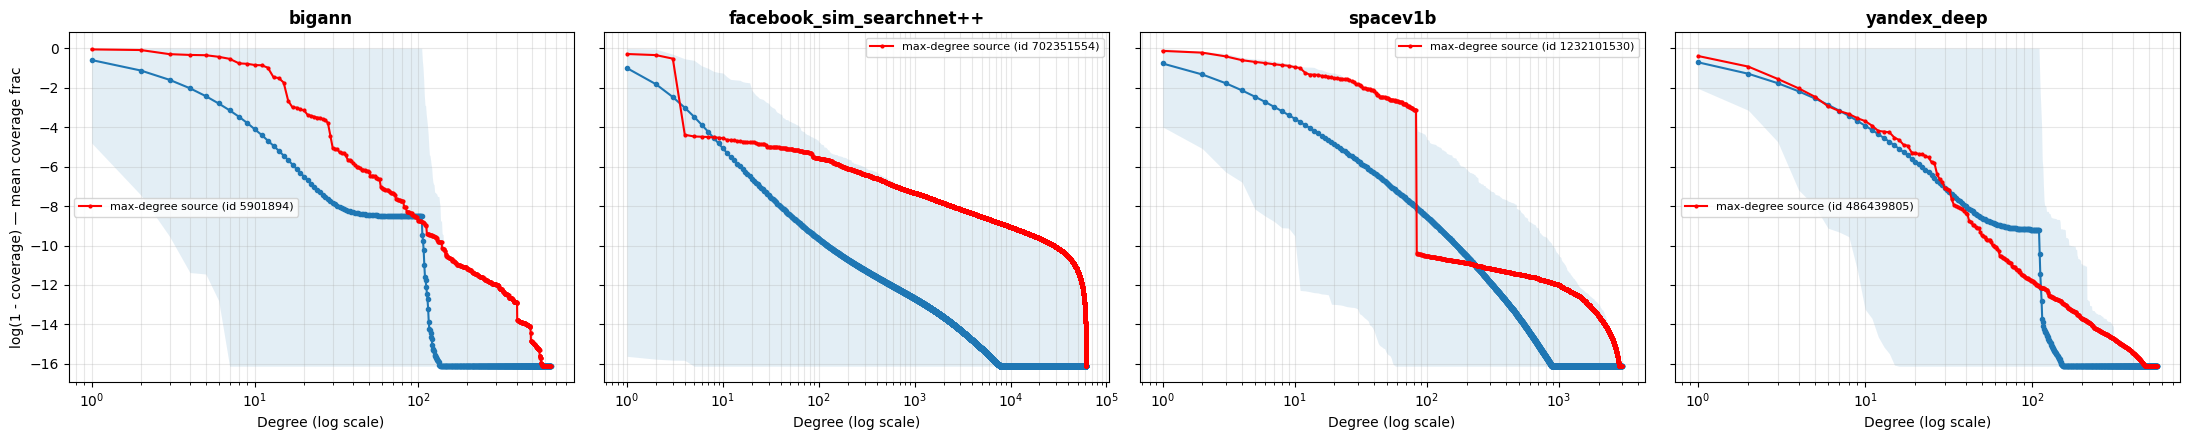

In [31]:
def plot_edges_vs_coverage(df, stat='mean coverage frac', show_band=True,
                           max_deg_curves=None, save_path=None):
    """One subplot per dataset: log(degree) (x) vs log(1 - coverage) (y).

    `edges` is the per-node out-degree, plotted on a log x-axis. `stat` names a
    covered-fraction column in [0, 1] (built in the load cell from the raw
    `... points covered` counts). We plot log(1 - coverage), i.e. the log of the
    remaining gap to full coverage; values near full coverage map to large-
    negative y. A separate curve is drawn per (metric, method) combination.

    If `max_deg_curves` is given (dataset -> per-source DataFrame from
    extract_max_degree_curve.py), the largest-out-degree source's own curve is
    overlaid in red, to expose whether drops in the aggregate come from a few
    high-degree outliers.
    """
    datasets = sorted(df['dataset'].unique())
    n_ds = len(datasets)

    # Floor the uncovered fraction so coverage == 1.0 doesn't blow up log().
    EPS = 1e-7

    def log_gap(cov_frac):
        gap = np.clip(1.0 - cov_frac, EPS, None)
        return np.log(gap)

    fig, axes = plt.subplots(
        1, n_ds, figsize=(5.5 * n_ds, 4.5), squeeze=False, sharey=True
    )

    for c, dataset in enumerate(datasets):
        ax = axes[0, c]
        sub = df[df['dataset'] == dataset]

        for (metric, method), grp in sub.groupby(['metric', 'method']):
            grp = grp.sort_values('edges')
            line, = ax.plot(grp['edges'], log_gap(grp[stat]), marker='o', markersize=3)
            if show_band:
                # Note: min coverage -> upper gap, max coverage -> lower gap.
                ax.fill_between(
                    grp['edges'], log_gap(grp['min coverage frac']), log_gap(grp['max coverage frac']),
                    color=line.get_color(), alpha=0.12, linewidth=0,
                )

        # Overlay the single largest-out-degree source in red.
        if max_deg_curves and dataset in max_deg_curves:
            cdf = max_deg_curves[dataset]
            src_id = cdf['source_id'].iloc[0] if 'source_id' in cdf.columns else '?'
            ax.plot(cdf['edges'], log_gap(cdf['coverage frac']),
                    color='red', linewidth=1.5, marker='.', markersize=4,
                    label=f'max-degree source (id {src_id})', zorder=5)
            ax.legend(fontsize=8)

        ax.set_title(dataset, fontweight='bold')
        ax.set_xscale('log')
        ax.set_xlabel('Degree (log scale)')
        if c == 0:
            ax.set_ylabel(f'log(1 - coverage) — {stat}')
        ax.grid(True, alpha=0.3, which='both')

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved -> {save_path}")
    plt.show()


plot_edges_vs_coverage(df, stat='mean coverage frac', show_band=True,
                       max_deg_curves=max_deg_curves)

In [ ]:
# --- Diagnose sharp drops: saturation cliff vs per-source geometric jump ---
# Load the diagnostics written by diagnose_coverage_drop.py (one _active.csv,
# one _degree_hist.csv, one _saturation_deciles.csv per dataset). Generate first:
#   python diagnose_coverage_drop.py \
#       --adj-list .../adj-list-bigann-euclidean.txt \
#       --computed .../bigann-euclidean-computed.txt \
#       --total-points 1000000000 --out ../edge_to_coverage/diag_bigann
DIAG_ACTIVE_GLOB = "../edge_to_coverage/diag_*_active.csv"
DIAG_HIST_GLOB   = "../edge_to_coverage/diag_*_degree_hist.csv"
DIAG_DEC_GLOB    = "../edge_to_coverage/diag_*_saturation_deciles.csv"

def _match_dataset(path):
    base = os.path.basename(path)
    return next((d for d in known_datasets if d in base), None)

active_by_ds = {}
hist_by_ds = {}
dec_by_ds = {}
for f in sorted(glob.glob(DIAG_ACTIVE_GLOB)):
    d = _match_dataset(f)
    if d:
        active_by_ds[d] = pd.read_csv(f).sort_values('edges')
for f in sorted(glob.glob(DIAG_HIST_GLOB)):
    d = _match_dataset(f)
    if d:
        hist_by_ds[d] = pd.read_csv(f).sort_values('out_degree')
for f in sorted(glob.glob(DIAG_DEC_GLOB)):
    d = _match_dataset(f)
    if d:
        dec_by_ds[d] = pd.read_csv(f)

# Edge count by which each decile of fully-covered sources saturates. A tight
# p10->p90 span means most sources finish over a narrow degree band => sharp
# cliff in the aggregate coverage curve; a wide span means a gradual approach.
if dec_by_ds:
    pcol, ecol = 'percentile of fully-covered sources', 'edges to reach full coverage'
    dec_table = pd.DataFrame({
        ds: t.set_index(pcol)[ecol] for ds, t in sorted(dec_by_ds.items())
    })
    print("Edges to reach full coverage, by decile of fully-covered sources:")
    print(dec_table.to_string())
    print("\np90/p10 spread (smaller = sharper cliff):")
    for ds in dec_table.columns:
        p10 = dec_table[ds].get(10); p90 = dec_table[ds].get(90)
        if p10 and p90:
            print(f"  {ds}: p10={int(p10)}  p90={int(p90)}  spread={p90/max(p10,1):.1f}x")

if not active_by_ds:
    print(f"No diagnostics found at {DIAG_ACTIVE_GLOB!r}. "
          "Run diagnose_coverage_drop.py to generate them.")
else:
    diag_datasets = sorted(active_by_ds)
    n = len(diag_datasets)
    EPS = 1e-7
    log_gap = lambda cf: np.log(np.clip(1.0 - cf, EPS, None))

    fig, axes = plt.subplots(2, n, figsize=(5.0 * n, 8), squeeze=False)
    for c, ds in enumerate(diag_datasets):
        a = active_by_ds[ds]

        # Row 0: log(1 - coverage) — ALL (clamped) vs ACTIVE-ONLY sources.
        # A cliff in ALL that is absent from ACTIVE-ONLY => saturation artifact.
        ax = axes[0, c]
        ax.plot(a['edges'], log_gap(a['mean cov frac (all, clamped)']),
                color='C0', marker='o', markersize=2, label='all (clamped)')
        ax.plot(a['edges'], log_gap(a['mean cov frac (active only)']),
                color='red', marker='.', markersize=3, label='active only')
        ax.set_xscale('log')
        ax.set_title(ds, fontweight='bold')
        ax.set_xlabel('Degree (log scale)')
        if c == 0:
            ax.set_ylabel('log(1 - mean coverage)')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=8)

        # Row 1: fraction of sources still active (out-degree > k) vs edges.
        # The cliff should line up with where this collapses.
        ax2 = axes[1, c]
        ax2.plot(a['edges'], a['frac_active'], color='C2', marker='.', markersize=3)
        ax2.set_xscale('log')
        ax2.set_xlabel('Degree (log scale)')
        if c == 0:
            ax2.set_ylabel('fraction of sources still active')
        ax2.set_ylim(-0.02, 1.02)
        ax2.grid(True, alpha=0.3, which='both')

    fig.tight_layout()
    plt.show()

    # Out-degree distribution (log-log) — a tight peak produces a sharp cliff.
    if hist_by_ds:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for ds in sorted(hist_by_ds):
            h = hist_by_ds[ds]
            ax.plot(h['out_degree'], h['n_sources'], marker='.', markersize=2, label=ds)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('Out-degree (log)'); ax.set_ylabel('num sources (log)')
        ax.set_title('Out-degree distribution')
        ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=8)
        fig.tight_layout(); plt.show()